# 01 — Reconocimiento del Terreno

**Misión:** Eres ingeniero biomédico. Te entregan datos de biopsias por aspiración con aguja fina (FNA) de **569 pacientes**. Antes de construir cualquier modelo, hay que **mapear el terreno**.

### ¿Qué tenemos?

Cada biopsia fue fotografiada bajo microscopio. Un algoritmo de visión computacional midió **10 características base** del núcleo celular:

> `radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave_points`, `symmetry`, `fractal_dimension`

Para cada una se calcularon **3 variantes estadísticas**:
- `_mean` — promedio de todos los núcleos en la imagen
- `_se` — error estándar (variabilidad entre núcleos)
- `_worst` — promedio de los 3 núcleos más extremos

**10 sensores × 3 lecturas = 30 features.** Más el diagnóstico: Maligno (M) o Benigno (B).

Pensalo como 30 sensores midiendo un motor. Algunos van a ser redundantes, otros van a ser clave. Nuestro trabajo: separar la señal del ruido.

---
## 1. Imports y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Colores del proyecto
COLOR_B = '#2ecc71'  # Benigno — verde
COLOR_M = '#e74c3c'  # Maligno — rojo
PALETTE = {'B': COLOR_B, 'M': COLOR_M}
PALETTE_NUM = {0: COLOR_B, 1: COLOR_M}

print("Librerías cargadas.")

Librerías cargadas.


---
## 2. Carga del Dataset

In [2]:
# Construcción de nombres de columnas
base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

column_names = ['id', 'diagnosis']
for suffix in ['_mean', '_se', '_worst']:
    column_names += [f + suffix for f in base_features]

print(f"Total columnas: {len(column_names)}")
print(column_names)

Total columnas: 32
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [3]:
# Rutas
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data", "breast_cancer")
data_path = os.path.join(data_dir, "wdbc.data")

print(f"Proyecto: {project_root}")
print(f"Datos:    {data_path}")
print(f"Existe:   {os.path.exists(data_path)}")

Proyecto: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos
Datos:    /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/breast_cancer/wdbc.data
Existe:   True


In [4]:
# Carga
df = pd.read_csv(data_path, header=None, names=column_names)
print(f"Shape original: {df.shape}")
df.head()

Shape original: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Limpieza: eliminar ID (no es feature), codificar diagnóstico
df.drop('id', axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f"Shape final: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")

Shape final: (569, 31)

Columnas: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


**Primer vistazo:** 569 filas, 31 columnas (30 features + diagnóstico). Cero nulos. Todas numéricas. Bien.

---
## 3. Balance de Clases

Pregunta crítica: ¿cuántos malignos vs benignos? Si hay un desbalance brutal, hay que tenerlo en cuenta después.

In [8]:
counts = df['diagnosis'].value_counts()
pcts = df['diagnosis'].value_counts(normalize=True) * 100

print("Distribución de diagnósticos:")
print(f"  Benigno (0): {counts[0]} ({pcts[0]:.1f}%)")
print(f"  Maligno (1): {counts[1]} ({pcts[1]:.1f}%)")

Distribución de diagnósticos:
  Benigno (0): 357 (62.7%)
  Maligno (1): 212 (37.3%)


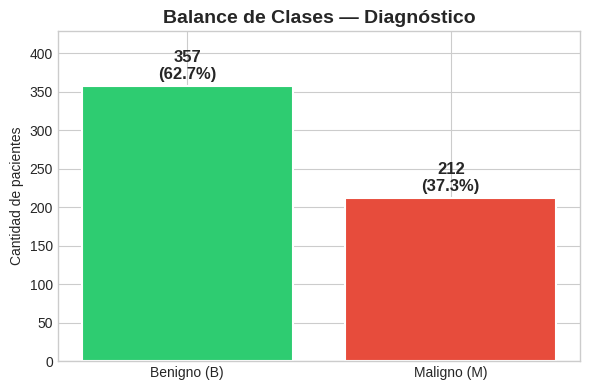

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Benigno (B)', 'Maligno (M)'], [counts[0], counts[1]],
              color=[COLOR_B, COLOR_M], edgecolor='white', linewidth=1.5)

for bar, count, pct in zip(bars, [counts[0], counts[1]], [pcts[0], pcts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Cantidad de pacientes')
ax.set_title('Balance de Clases — Diagnóstico', fontweight='bold', fontsize=14)
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.show()

**Veredicto:** 62.7% Benigno, 37.3% Maligno. Hay desbalance moderado pero no extremo. Suficiente para trabajar sin oversampling agresivo, pero usaremos `stratify` en el split.

---
## 4. Distribuciones Univariadas

30 features, 30 histogramas. ¿Cuáles separan bien M de B? Esa es la pregunta.

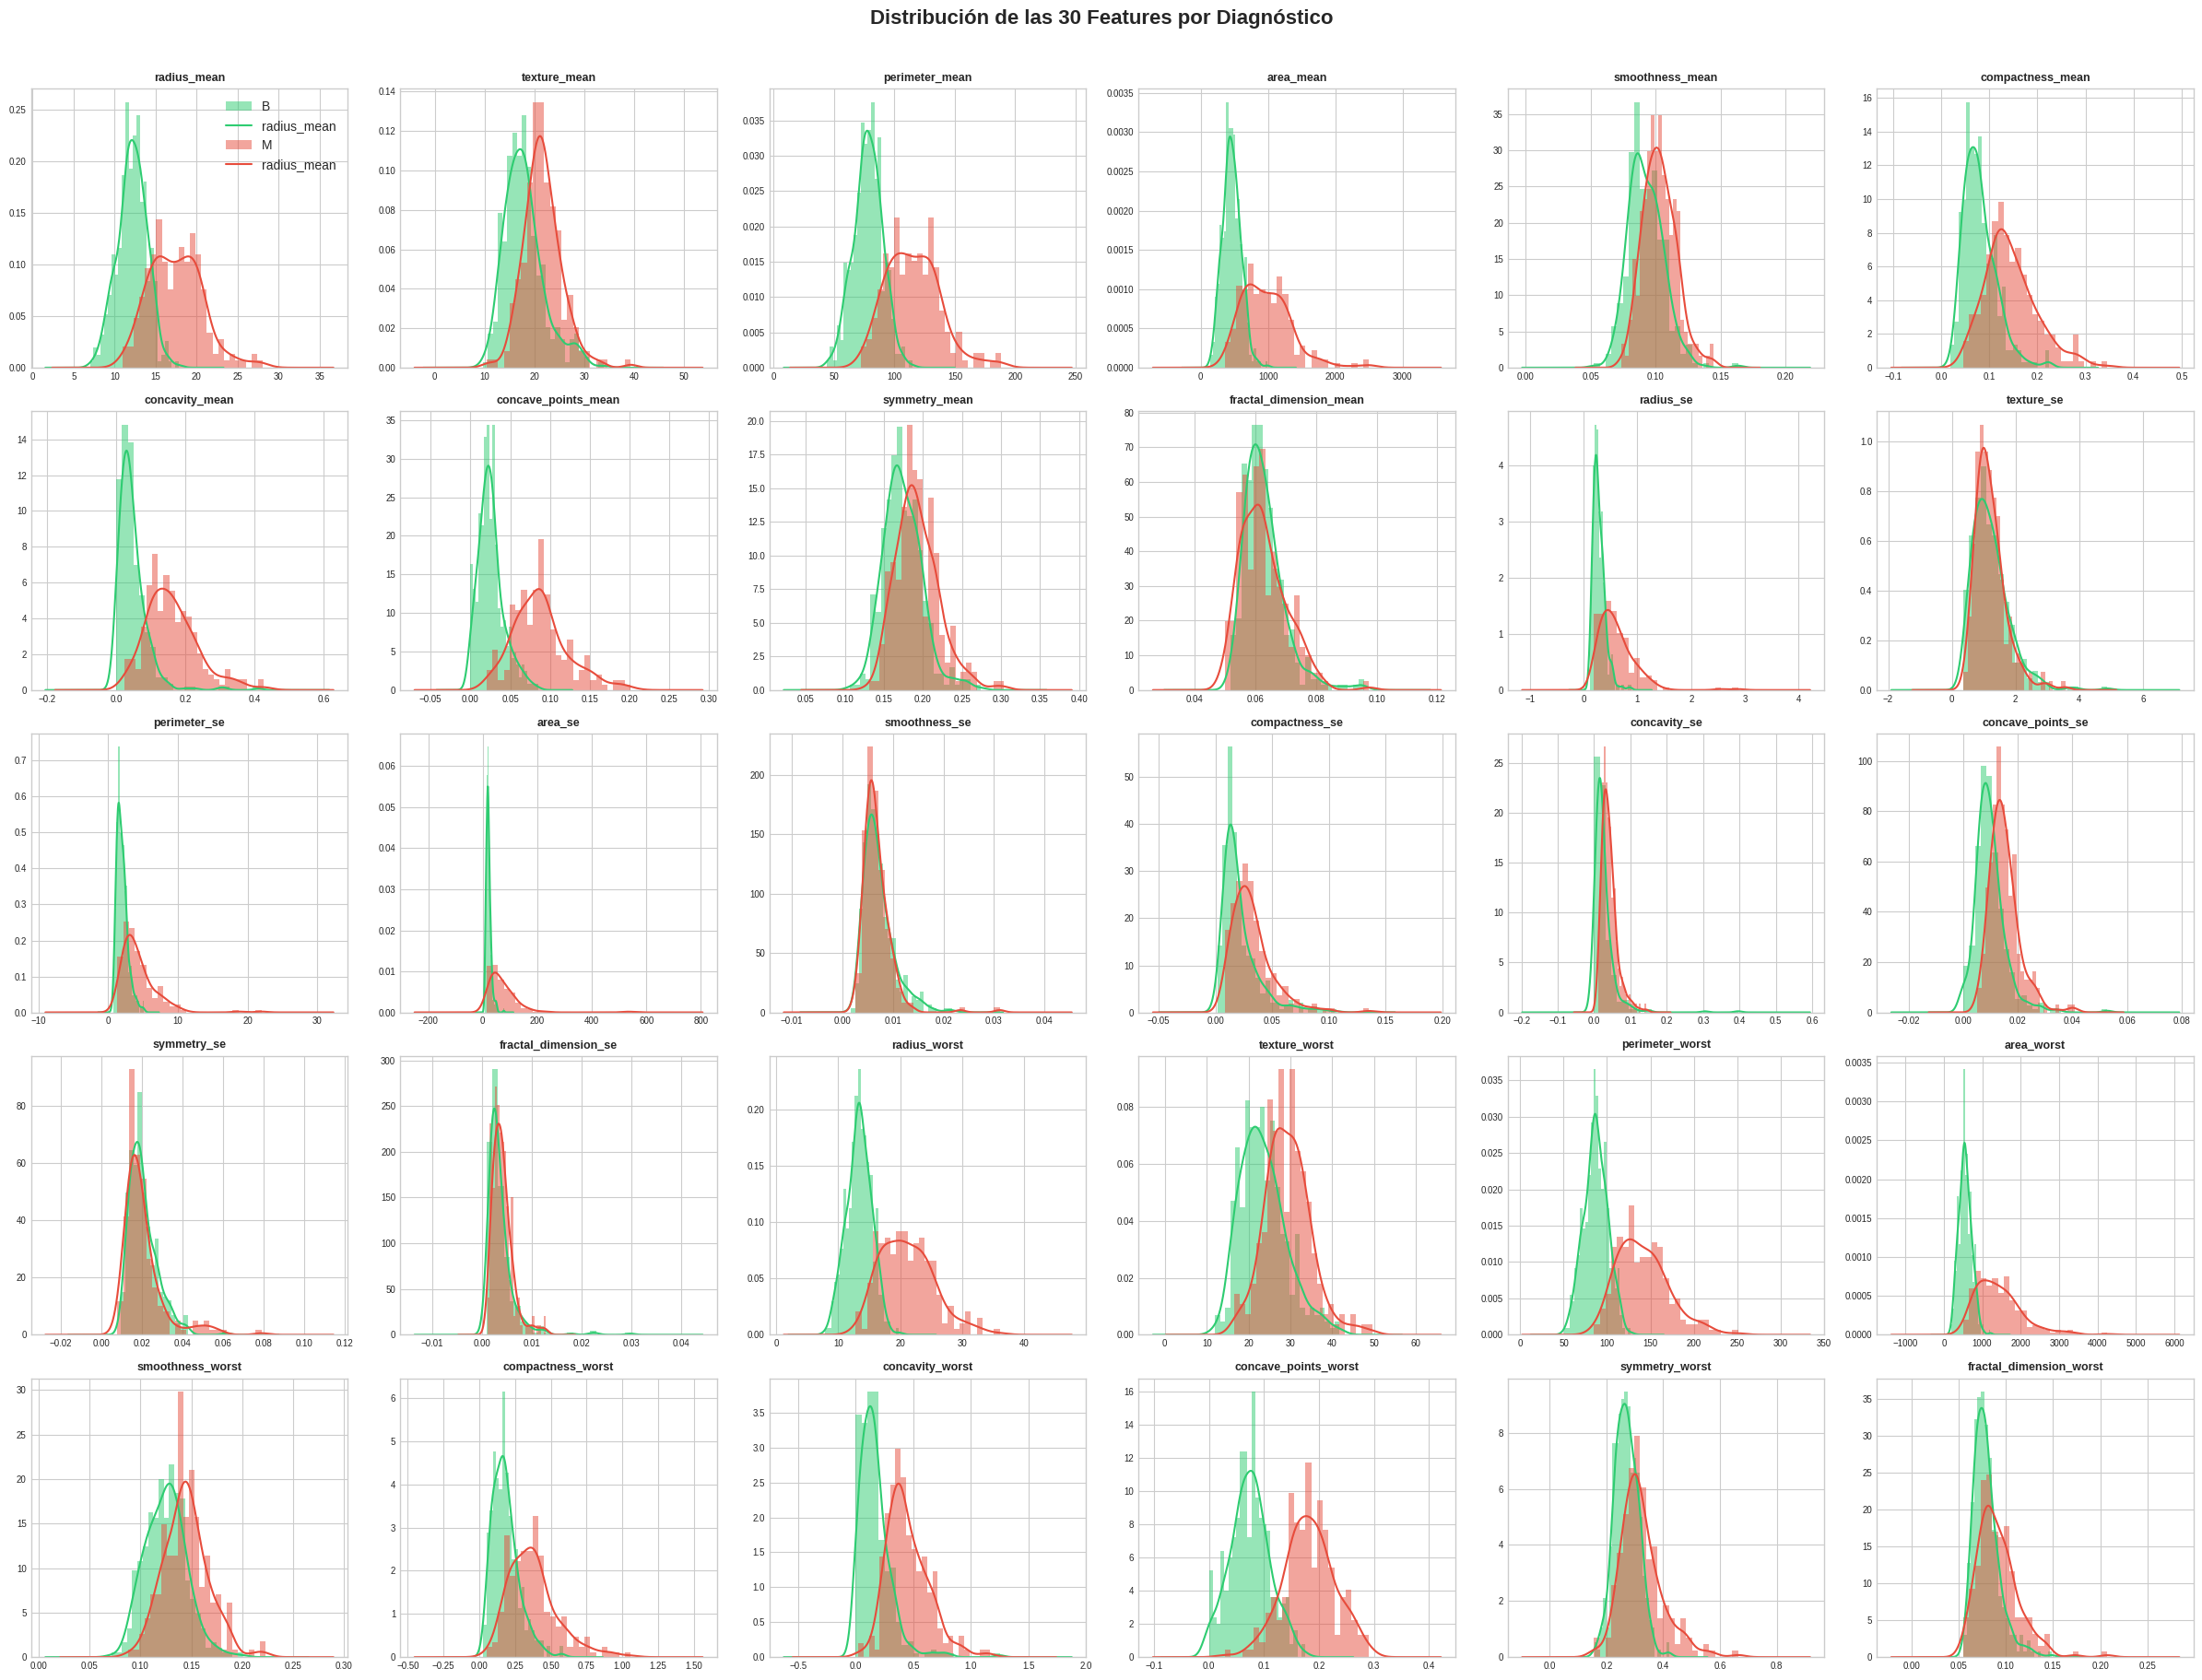

In [10]:
features = [c for c in df.columns if c != 'diagnosis']

fig, axes = plt.subplots(5, 6, figsize=(24, 18))
axes = axes.ravel()

for i, feat in enumerate(features):
    ax = axes[i]
    # Benigno
    ax.hist(df[df['diagnosis'] == 0][feat], bins=25, alpha=0.5,
            color=COLOR_B, label='B', density=True)
    df[df['diagnosis'] == 0][feat].plot.kde(ax=ax, color=COLOR_B, linewidth=1.5)
    # Maligno
    ax.hist(df[df['diagnosis'] == 1][feat], bins=25, alpha=0.5,
            color=COLOR_M, label='M', density=True)
    df[df['diagnosis'] == 1][feat].plot.kde(ax=ax, color=COLOR_M, linewidth=1.5)
    
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=10)
fig.suptitle('Distribución de las 30 Features por Diagnóstico', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Observaciones clave:

- **`_mean` y `_worst`** muestran separación clara entre M y B en la mayoría de features. Son las lecturas más discriminativas.
- **`_se`** (error estándar) es menos discriminativo. Las distribuciones se solapan mucho más.
- Features con mejor separación visual: `concave_points_mean`, `concavity_mean`, `radius_worst`, `perimeter_worst`, `area_worst`.
- `smoothness_se`, `symmetry_se`, `fractal_dimension_se` — prácticamente inútiles a simple vista.

---
## 5. Box Plots — Top 10 Features Mean

Las features `_mean` son el primer grupo de sensores. Veamos su rango y dispersión lado a lado.

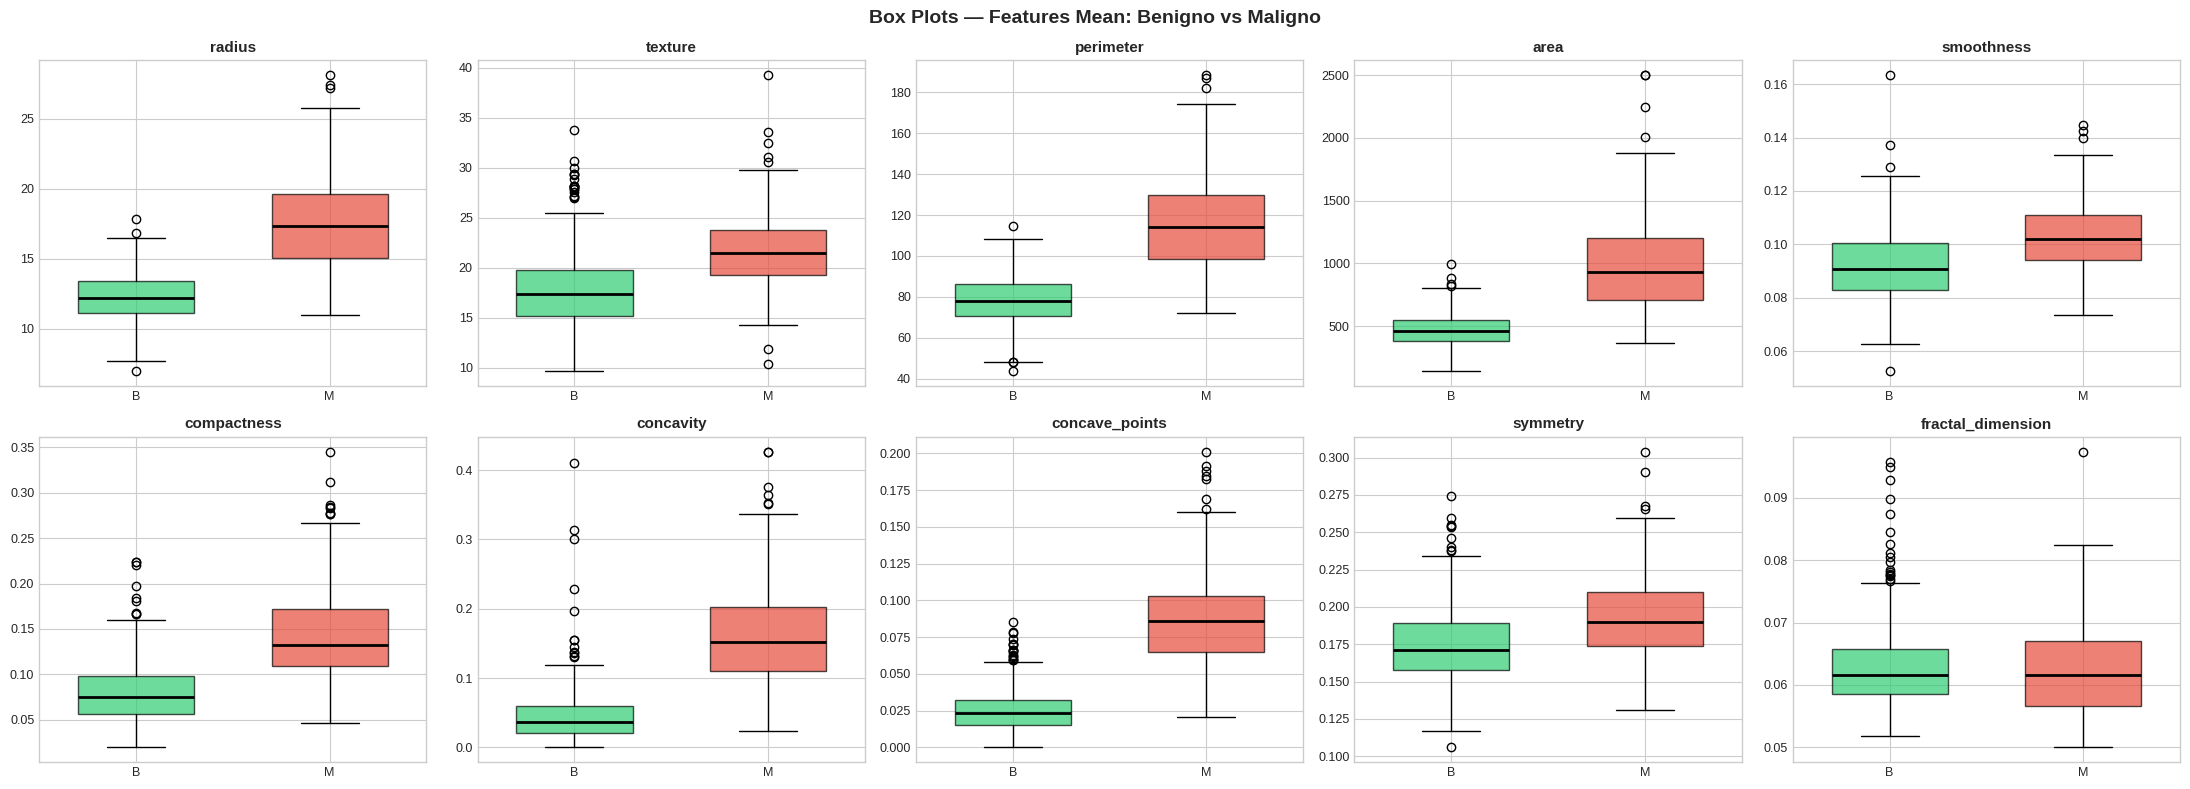

In [11]:
mean_features = [f + '_mean' for f in base_features]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.ravel()

for i, feat in enumerate(mean_features):
    ax = axes[i]
    data_b = df[df['diagnosis'] == 0][feat]
    data_m = df[df['diagnosis'] == 1][feat]
    
    bp = ax.boxplot([data_b, data_m], labels=['B', 'M'], patch_artist=True,
                    widths=0.6, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLOR_B)
    bp['boxes'][1].set_facecolor(COLOR_M)
    for box in bp['boxes']:
        box.set_alpha(0.7)
    
    ax.set_title(feat.replace('_mean', ''), fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)

fig.suptitle('Box Plots — Features Mean: Benigno vs Maligno', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Lo que salta a la vista:**
- `radius`, `perimeter`, `area`, `concavity`, `concave_points` — medianas muy separadas. Buenos discriminadores.
- `smoothness`, `symmetry`, `fractal_dimension` — mucho solapamiento. Discriminan poco por sí solas.
- `area` tiene outliers enormes en malignos. Ojo con eso al escalar.

---
## 6. Matriz de Correlación

Con 30 features, seguro hay redundancia. Si dos sensores miden lo mismo, uno sobra.

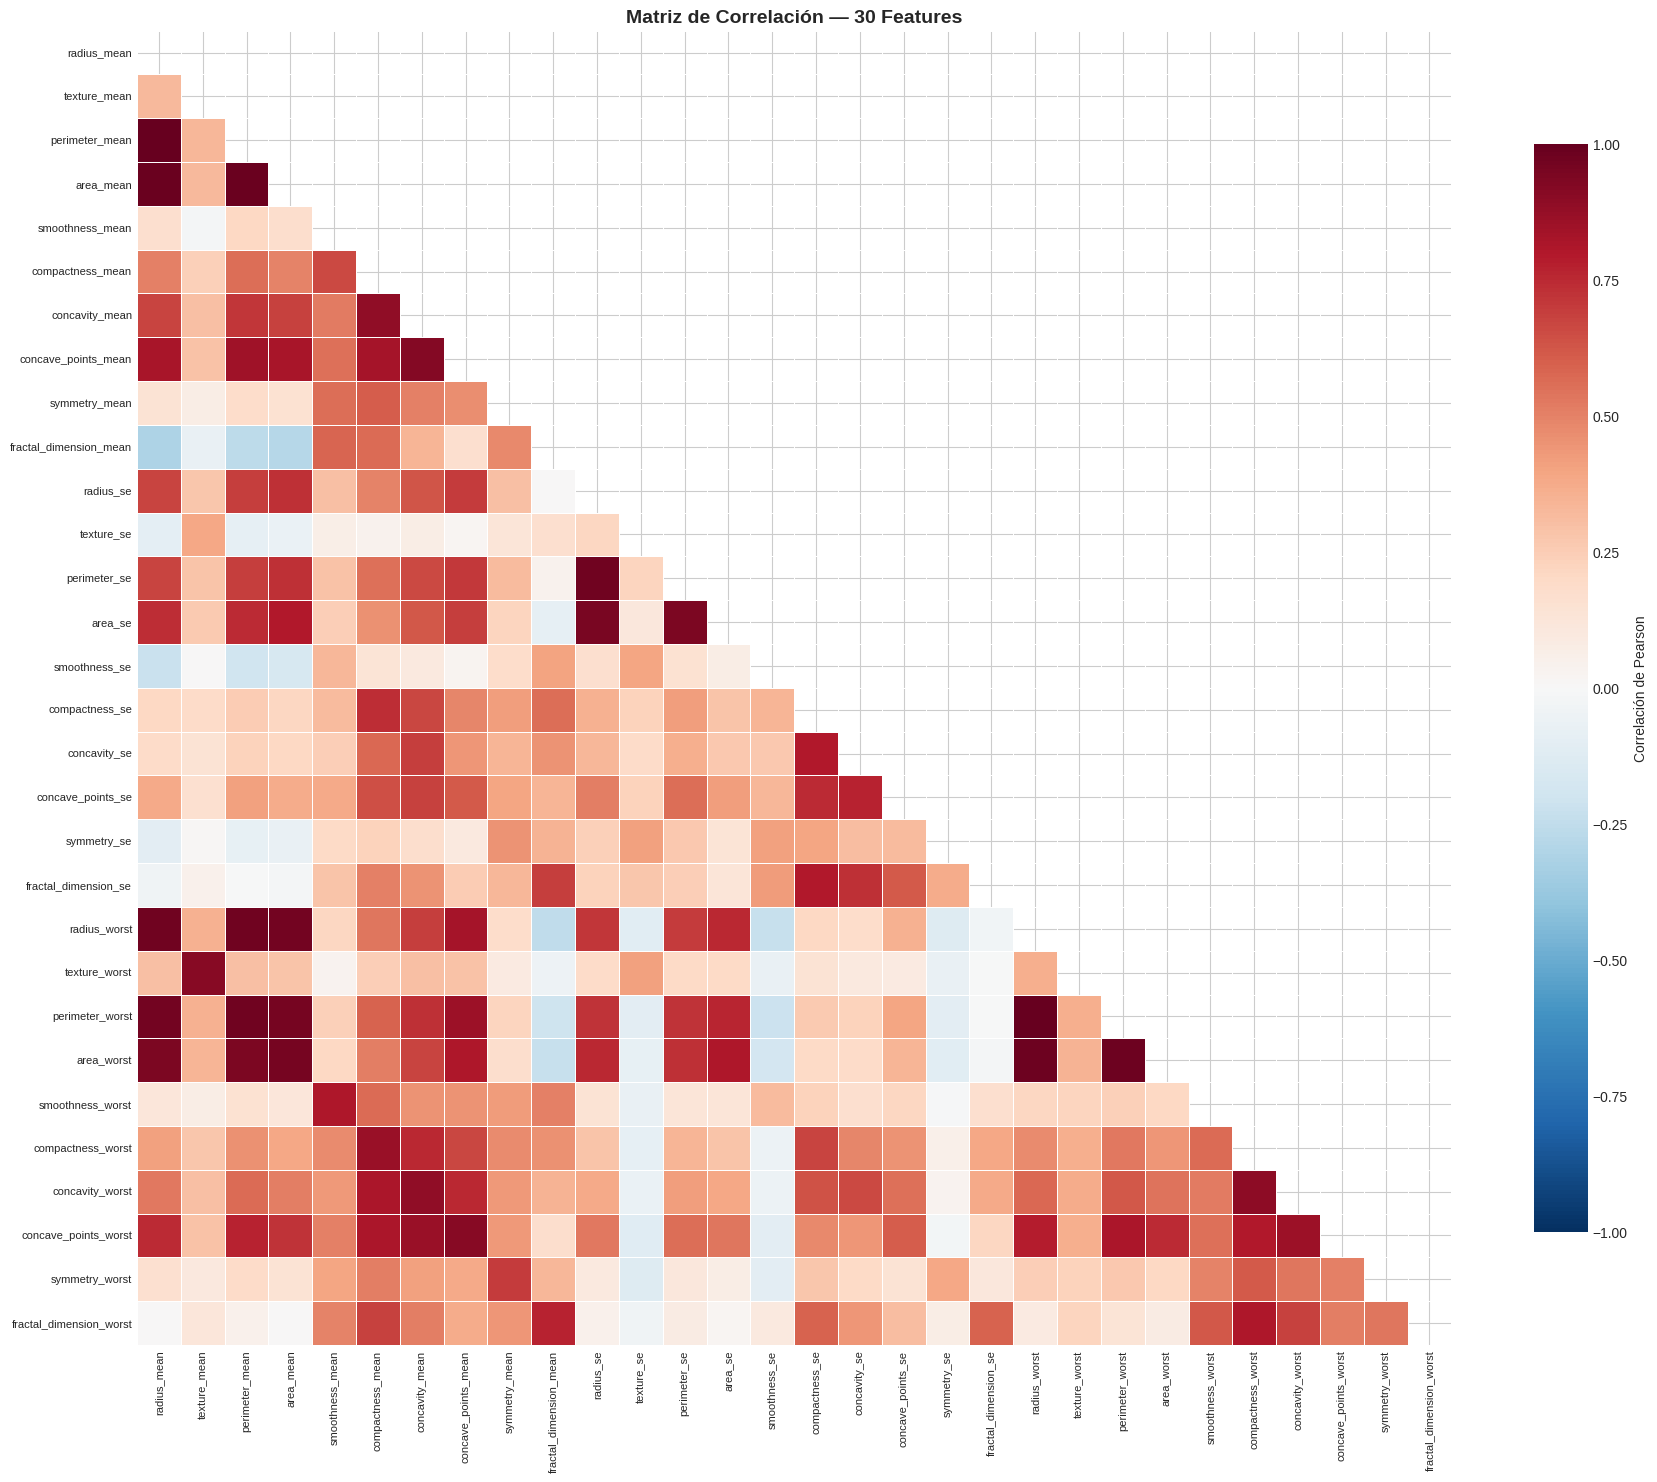

In [12]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
            vmin=-1, vmax=1)

ax.set_title('Matriz de Correlación — 30 Features', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Pares con correlación > 0.95
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr_pairs.append({
                'Feature 1': corr.columns[i],
                'Feature 2': corr.columns[j],
                'Correlación': round(corr.iloc[i, j], 4)
            })

df_high_corr = pd.DataFrame(high_corr_pairs).sort_values('Correlación', ascending=False)
print(f"Pares con |r| > 0.95: {len(df_high_corr)}")
df_high_corr

Pares con |r| > 0.95: 15


,Feature 1,Feature 2,Correlación
0,radius_mean,perimeter_mean,0.9979
12,radius_worst,perimeter_worst,0.9937
1,radius_mean,area_mean,0.9874
4,perimeter_mean,area_mean,0.9865
13,radius_worst,area_worst,0.9840
14,perimeter_worst,area_worst,0.9776
10,radius_se,perimeter_se,0.9728
6,perimeter_mean,perimeter_worst,0.9704
2,radius_mean,radius_worst,0.9695
5,perimeter_mean,radius_worst,0.9695


### Hallazgos de correlación:

- **radius / perimeter / area** están casi perfectamente correlacionados (r > 0.98) en las 3 variantes. Tiene sentido: si el radio crece, el perímetro y el área también. Son medidas redundantes del **tamaño**.
- **compactness / concavity / concave_points** también correlacionados fuertemente. Miden diferentes aspectos de la **irregularidad** del contorno.
- En el notebook de preprocesamiento vamos a eliminar las redundantes.

---
## 7. Pair Plot — 5 Features Más Prometedoras

Seleccionamos features con buena separación visual y que midan cosas diferentes.

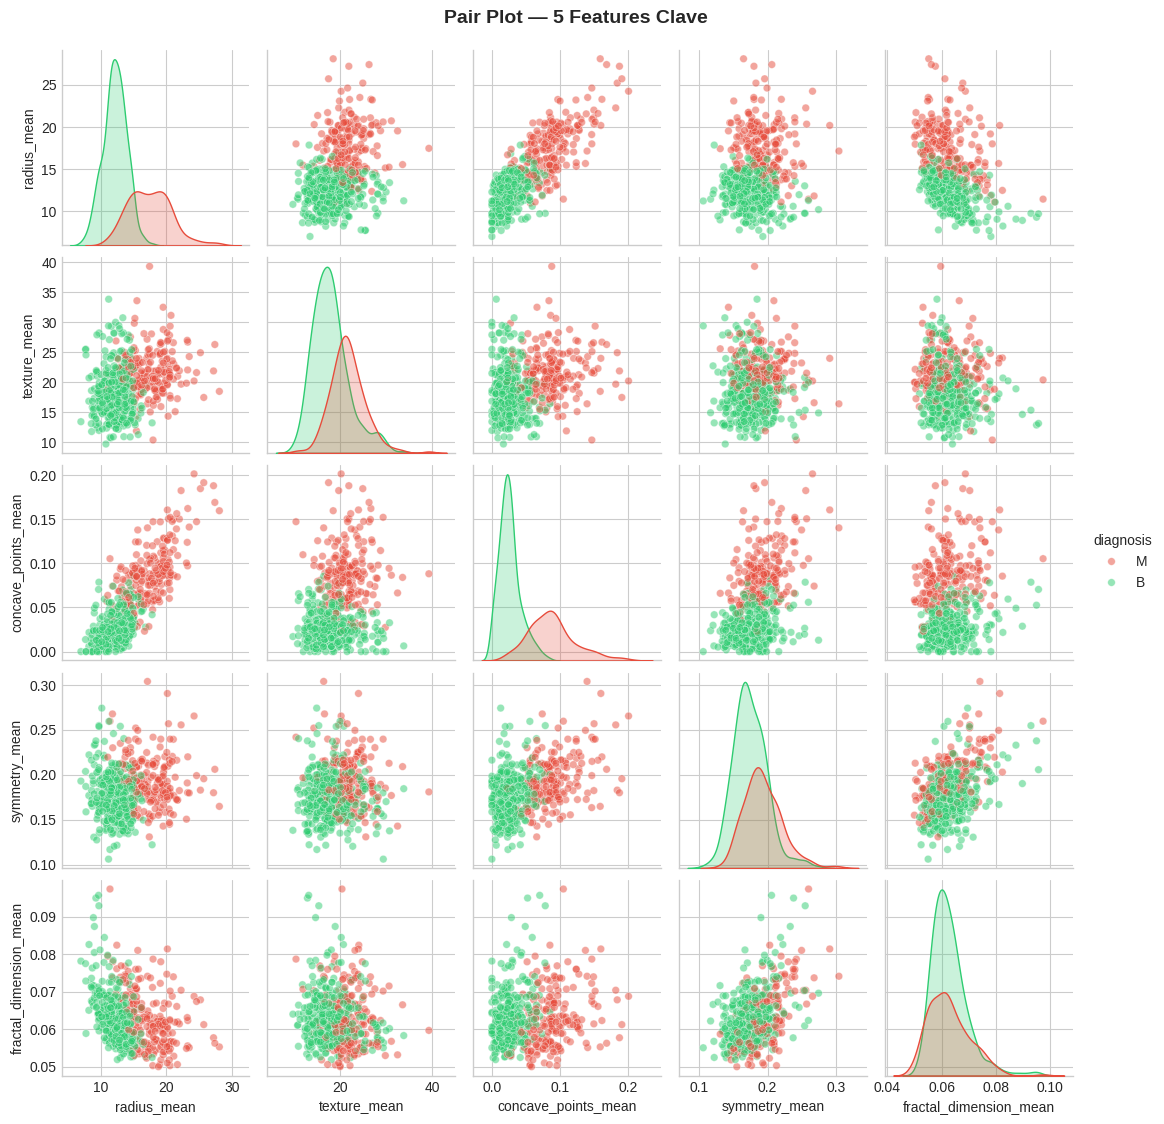

In [14]:
top_features = ['radius_mean', 'texture_mean', 'concave_points_mean',
                'symmetry_mean', 'fractal_dimension_mean']

df_plot = df[top_features + ['diagnosis']].copy()
df_plot['diagnosis'] = df_plot['diagnosis'].map({0: 'B', 1: 'M'})

g = sns.pairplot(df_plot, hue='diagnosis', palette=PALETTE,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 height=2.2)
g.figure.suptitle('Pair Plot — 5 Features Clave', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### Lo que revela el pair plot:

- **radius_mean vs concave_points_mean:** excelente separación. El combo tamaño + irregularidad distingue bien.
- **texture_mean:** aporta información diferente (textura del núcleo), buen complemento.
- **symmetry_mean y fractal_dimension_mean:** menos discriminativas por sí solas, pero aportan diversidad al feature set.
- Los clusters son separables pero no linealmente puros — un modelo lineal podría funcionar, pero uno no-lineal probablemente sea mejor.

---
## 8. Correlación con el Diagnóstico

¿Cuáles features están más correlacionadas con ser maligno?

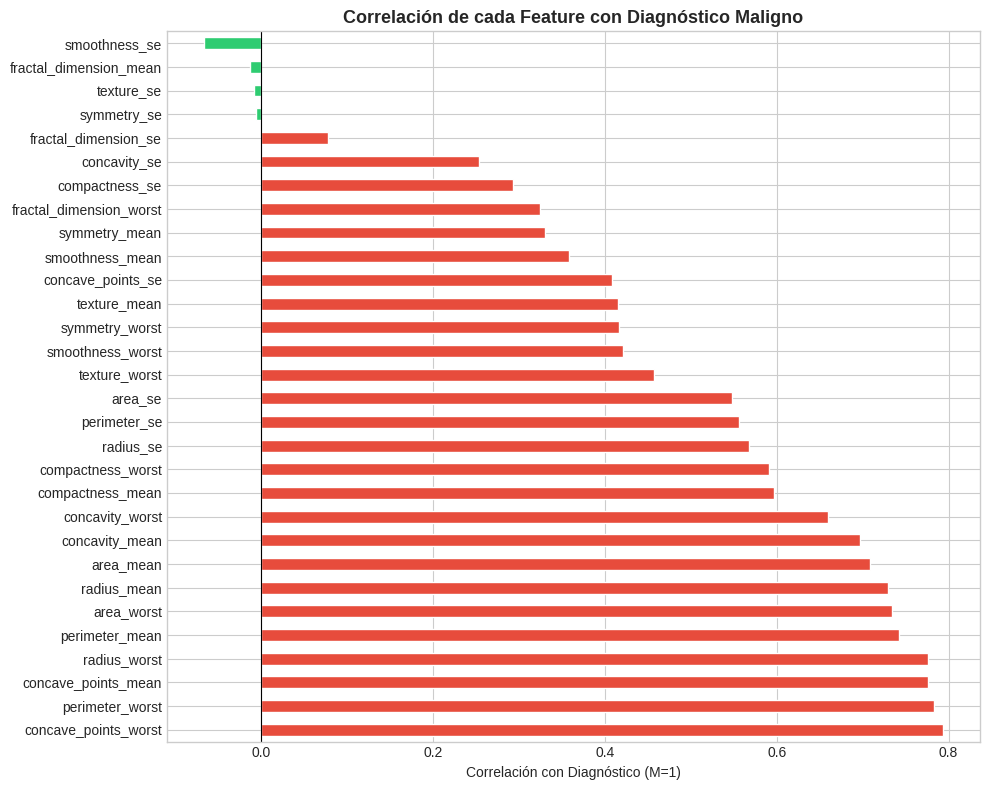

In [15]:
corr_with_target = df[features].corrwith(df['diagnosis']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLOR_M if v > 0 else COLOR_B for v in corr_with_target.values]
corr_with_target.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Correlación con Diagnóstico (M=1)')
ax.set_title('Correlación de cada Feature con Diagnóstico Maligno', fontweight='bold', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Top correlaciones positivas (asociadas a Maligno):**
- `concave_points_worst`, `perimeter_worst`, `concave_points_mean`, `radius_worst` — todos > 0.7
- Confirma lo que vimos: tamaño + irregularidad = señales fuertes de malignidad.

**Correlaciones débiles/negativas:**
- `fractal_dimension_mean`, `texture_se`, `smoothness_se` — prácticamente irrelevantes.

---
## 9. Resumen del Reconocimiento

### Lo que sabemos:

| Aspecto | Hallazgo |
|---|---|
| **Datos** | 569 muestras, 30 features, 0 nulos |
| **Balance** | 62.7% B / 37.3% M — moderado, manejable con stratify |
| **Mejores sensores** | `concave_points`, `radius`, `perimeter`, `area` (en mean y worst) |
| **Sensores débiles** | `fractal_dimension_se`, `smoothness_se`, `symmetry_se` |
| **Redundancia** | radius/perimeter/area casi idénticos (r > 0.98). Hay que podar. |
| **Variantes** | `_mean` y `_worst` discriminan bien, `_se` menos |

### Siguiente paso:

**→ Notebook 02: Preprocesamiento.** Escalar features (los rangos son muy diferentes), eliminar redundancias, preparar train/test split.